# P3 · RFM 客户分层练习

**目标**：给 800 个客户按 RFM 打分、分成 8 类，并写出每类的运营建议。
标 `【TODO】` 的格子自己完成，`Shift+Enter` 执行。做完再对 `P3_RFM参考答案.ipynb`。

## 什么是 RFM

| 字母 | 含义 | 怎么算 | 业务解读 |
|---|---|---|---|
| **R** Recency | 最近一次消费距今天数 | 基准日 − 该客户最后下单日 | **越小越好**，越近越可能复购 |
| **F** Frequency | 消费频次 | 该客户的唯一订单数 | 越大越好，忠诚度高 |
| **M** Monetary | 消费金额 | 该客户销售总额 | 越大越好，贡献高 |

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP','SimHei','Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

## 1. 加载并聚合出 RFM

In [3]:
df = pd.read_csv('superstore.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-','_').str.lower()
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2018-367753,2016-11-02,11/08/2016,Standard Class,XX-10136,Customer_137,Consumer,United States,Los Angeles,...,90001,West,PROD-OFF-0104,Office Supplies,Art,Art 2,3.82,1,0.7,-0.01
1,2,CA-2018-867710,2016-09-16,09/19/2016,Second Class,XX-10420,Customer_421,Corporate,United States,Baltimore,...,21201,East,PROD-OFF-0093,Office Supplies,Labels,Labels 3,19.56,3,0.4,6.49


In [4]:
# 【TODO】设定基准日 = 数据中最晚下单日 + 1 天
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)
print('基准日：', snapshot_date.date())

# 【TODO】按 customer_id 聚合出 recency / frequency / monetary
rfm = df.groupby('customer_id').agg(
    recency  =('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary =('sales', 'sum'))
rfm.head()

基准日： 2018-12-29


,recency,frequency,monetary
customer_id,,,
XX-10000,88,15,4257.20
XX-10001,85,10,1829.71
XX-10002,4,8,824.89
XX-10003,150,20,13613.24
XX-10004,48,12,4378.91


## 2. 五等分打分（1-5 分）

用 `pd.qcut` 按分位数分 5 档：
- F、M：越大分越高（`labels=[1,2,3,4,5]`）
- **R 相反**：天数越小分越高（`labels=[5,4,3,2,1]`），这是 RFM 最易错的点。

In [5]:
# 【TODO】给 R/F/M 打 1-5 分（注意 R 反向）
rfm['r_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'], 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])
rfm[['r_score','f_score','m_score']] = rfm[['r_score','f_score','m_score']].astype(int)
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score
customer_id,,,,,,
XX-10000,88,15,4257.20,3,4,3
XX-10001,85,10,1829.71,3,1,1
XX-10002,4,8,824.89,5,1,1
XX-10003,150,20,13613.24,2,5,5
XX-10004,48,12,4378.91,4,3,3


## 3. 判定高/低，分成 8 类

做法：用三个分数各自与**平均分（3 分）**比较，高于平均 = 高，低于等于 = 低。
再按 R/F/M 高低组合映射成 8 类客户。

In [6]:
# 【TODO】判定每个分数是否高于该列平均值
rfm['r_high'] = rfm['r_score'] > rfm['r_score'].mean()
rfm['f_high'] = rfm['f_score'] > rfm['f_score'].mean()
rfm['m_high'] = rfm['m_score'] > rfm['m_score'].mean()


# 【TODO】把 8 个分支的客户名补全
def label_customer(row):
    R, F, M = row['r_high'], row['f_high'], row['m_high']
    if M:
        if R and F: return '重要价值客户'
        if R and not F: return '重要发展客户'
        if not R and F: return '重要保持客户'
        return '重要挽留客户'
    else:
        if R and F: return '一般价值客户'
        if R and not F: return '一般发展客户'
        if not R and F: return '一般保持客户'
        return '一般挽留客户'

rfm['segment_rfm'] = rfm.apply(label_customer, axis=1)
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,r_high,f_high,m_high,segment_rfm
customer_id,,,,,,,,,,
XX-10000,88,15,4257.20,3,4,3,False,True,False,一般保持客户
XX-10001,85,10,1829.71,3,1,1,False,False,False,一般挽留客户
XX-10002,4,8,824.89,5,1,1,True,False,False,一般发展客户
XX-10003,150,20,13613.24,2,5,5,False,True,True,重要保持客户
XX-10004,48,12,4378.91,4,3,3,True,True,False,一般价值客户


## 4. 汇总各类客户

In [7]:
# 【TODO】按 segment_rfm 汇总，按总销售额降序
summary = rfm.groupby('segment_rfm').agg(
    客户数=('monetary','size'),
    平均R天=('recency','mean'),
    平均F次=('frequency','mean'),
    总销售额=('monetary','sum'),
    平均销售额=('monetary','mean')).round(1).sort_values('总销售额', ascending=False)
summary['人数占比%'] = (summary['客户数']/summary['客户数'].sum()*100).round(1)
summary

,客户数,平均R天,平均F次,总销售额,平均销售额,人数占比%
segment_rfm,,,,,,
重要保持客户,131,128.4,14.8,1133740.3,8654.5,16.4
重要价值客户,117,24.7,15.7,1025901.1,8768.4,14.6
一般挽留客户,184,211.1,9.1,450933.9,2450.7,23.0
重要挽留客户,50,157.2,9.7,399073.6,7981.5,6.2
一般价值客户,109,26.5,14.6,385841.7,3539.8,13.6
一般保持客户,111,122.8,14.0,349319.9,3147.0,13.9
一般发展客户,76,26.2,9.3,196702.9,2588.2,9.5
重要发展客户,22,26.0,10.0,162567.8,7389.4,2.8


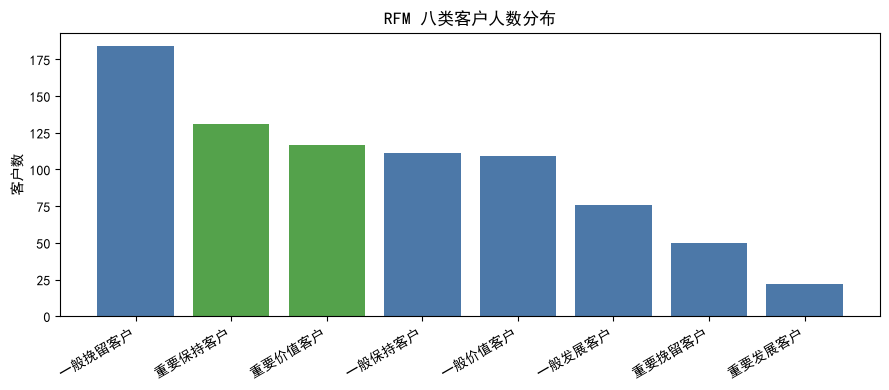

In [8]:
# 8 类客户人数分布柱状图
plt.figure(figsize=(9,4))
cnt = rfm['segment_rfm'].value_counts()
colors = ['#54A24B' if ('重要价值' in s or '重要保持' in s) else '#4C78A8' for s in cnt.index]
plt.bar(range(len(cnt)), cnt.values, color=colors)
plt.xticks(range(len(cnt)), cnt.index, rotation=30, ha='right')
plt.ylabel('客户数'); plt.title('RFM 八类客户人数分布')
plt.tight_layout(); plt.savefig('rfm_segment_dist.png', dpi=100);  plt.show()

## 5. 运营建议（每类写 1-2 条）

| 客户类型 | 特征 | 运营策略 |
|---|---|---|
| 重要价值客户 | 近、频、高额 | VIP 专属权益、新品优先、会员升级，重点维护 |
| 重要发展客户 | 近期买过、高额但频次低 | 提升复购：满减券、定期购、交叉推荐 |
| 重要保持客户 | 高频高额但很久没来 | 召回：专属折扣、流失预警、短信关怀 |
| 重要挽留客户 | 曾经高额、低频且疏远 | 强力召回券、问卷调研找流失原因 |
| 一般价值客户 | 近期高频但金额低 | 提客单价：高毛利商品推荐、满额包邮 |
| 一般发展客户 | 新客、低频低额 | 培养习惯：新人任务、第二单优惠 |
| 一般保持客户 | 高频低额、疏远 | 低成本触达：内容推送、活动通知 |
| 一般挽留客户 | 全面低 | 不投入过多资源，合并到批量营销 |

## 6. 结论

- RFM 用三个行为维度把 800 个客户客观分成 8 类，**比单纯按消费额分层更能指导运营动作**。
- 资源应优先投向"重要"四类：价值客户做维护、发展客户提频、保持/挽留客户做召回。

In [9]:
rfm.reset_index().to_csv('rfm_result.csv', index=False, encoding='utf-8-sig')
print('已导出 rfm_result.csv，行数：', len(rfm))

已导出 rfm_result.csv，行数： 800


In [10]:
# 导出为CSV文件，设置utf-8-sig编码避免Excel打开中文乱码，保留索引（也就是segment_rfm客户分群名称）
summary.to_csv("RFM客户分群汇总.csv", encoding="utf-8-sig", index=True)